# SWaT ICS — Full ML Pipeline (Final)
### Secure Water Treatment · 9 Attack Classes · 4 Runs Merged

**Changes from previous version:**
- `DEAD_COLS` trimmed — keeps `DPIT_301`, `FIT_301`, `AIT_501-504`, `FIT_501-504`, `PIT_501-503`, `FIT_601`, `MV_303/304`, `UF_Backwash_Active`, `UV_401`, all `P_*` except confirmed dead
- `ReduceLROnPlateau` `verbose` argument removed (PyTorch ≥2.2 compatibility)
- Run-based generalisation test added (train runs 1–3, test run 4)

| Section | Content |
|---------|---------|
| 0 | Imports & config |
| 1 | Data loading & class distribution |
| 2 | Preprocessing — updated DEAD_COLS |
| 3 | Temporal feature engineering |
| 4 | NaN audit & clean matrix |
| 5 | Train/test split + scaling |
| 6 | Run-based generalisation test |
| 7 | Class balancing (SMOTE) |
| 8 | Classical ML — binary |
| 9 | Classical ML — multi-class |
| 10 | MLP neural network |
| 11 | BiLSTM + Attention |
| 12 | Full evaluation & plots |
| 13 | Save all models |
| 14 | Inference demo |


## 0 · Imports & Configuration

In [25]:
# !pip install scikit-learn xgboost imbalanced-learn joblib torch matplotlib seaborn pandas numpy

import os, warnings, json as _json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import joblib
import xgboost as xgb
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}  |  XGBoost: {xgb.__version__}")

MODELS_DIR = Path("saved_models"); MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR  = Path("plots");        PLOTS_DIR.mkdir(exist_ok=True)

ATTACK_NAMES = {
    0:"Normal Operation",       1:"Tank Overflow Attack",
    2:"Chemical Depletion Attack", 3:"Membrane Damage Attack",
    4:"pH Manipulation Attack", 5:"Slow Ramp Attack",
    6:"Reconnaissance Scan",    7:"Denial of Service",
    8:"Replay Attack",          9:"Valve Manipulation Attack",
}
NUM_CLASSES = 10
ID_REMAP    = {0:0, 8:1, 9:2, 10:3, 11:4, 12:5, 13:6, 14:7, 15:8, 16:9}
PALETTE     = ['#1565C0','#E53935','#2E7D32','#F57F17','#6A1B9A',
               '#00838F','#AD1457','#37474F','#558B2F','#4E342E']


Device : cpu
PyTorch: 2.10.0+cpu  |  XGBoost: 3.2.0


## 1 · Data Loading

In [26]:
DATA_PATH = "final.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw['ATTACK_ID']   = df_raw['ATTACK_ID'].map(ID_REMAP)
df_raw['ATTACK_NAME'] = df_raw['ATTACK_ID'].map(ATTACK_NAMES)
df_raw['ts']          = pd.to_datetime(df_raw['Timestamp'])
df_raw = df_raw.sort_values(['run_id','elapsed_seconds']).reset_index(drop=True)

print(f"Shape : {df_raw.shape}")
print(f"Runs  : {sorted(df_raw['run_id'].unique())}")
print(f"Missing: {df_raw.isnull().sum().sum()}  |  Duplicates: {df_raw.duplicated().sum()}")

dist = df_raw.groupby(['ATTACK_ID','ATTACK_NAME']).size().reset_index(name='rows')
dist['pct'] = (dist['rows']/len(df_raw)*100).round(2)
print("\n", dist.to_string(index=False))


Shape : (130483, 76)
Runs  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Missing: 0  |  Duplicates: 0

  ATTACK_ID               ATTACK_NAME  rows   pct
         0          Normal Operation 90337 69.23
         1      Tank Overflow Attack  4790  3.67
         2 Chemical Depletion Attack  1594  1.22
         3    Membrane Damage Attack  2475  1.90
         4    pH Manipulation Attack  5493  4.21
         5          Slow Ramp Attack  6299  4.83
         6       Reconnaissance Scan  6352  4.87
         7         Denial of Service  1941  1.49
         8             Replay Attack  5025  3.85
         9 Valve Manipulation Attack  6177  4.73


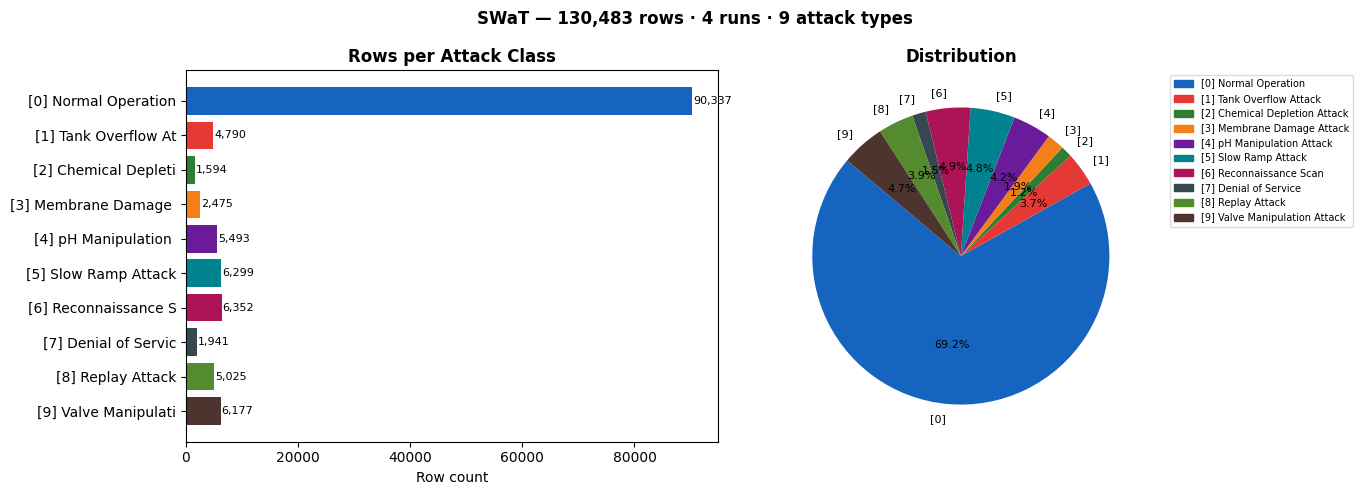

In [27]:
# ── Class distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_raw.groupby('ATTACK_ID').size()
short  = [f"[{i}] {ATTACK_NAMES[i][:16]}" for i in counts.index]

axes[0].barh(short[::-1], counts.values[::-1], color=[PALETTE[i] for i in counts.index[::-1]])
axes[0].set_xlabel("Row count")
axes[0].set_title("Rows per Attack Class", fontweight='bold')
for i, v in enumerate(counts.values[::-1]):
    axes[0].text(v+200, i, f"{v:,}", va='center', fontsize=8)

axes[1].pie(counts.values, labels=[f"[{i}]" for i in counts.index],
            colors=PALETTE, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':8})
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=PALETTE[i], label=f"[{i}] {ATTACK_NAMES[i]}") for i in range(10)]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05,1), fontsize=7, framealpha=0.7)
axes[1].set_title("Distribution", fontweight='bold')

plt.suptitle(f"SWaT — {len(df_raw):,} rows · 4 runs · 9 attack types",
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"01_class_dist.png", dpi=150, bbox_inches='tight')
plt.show()


## 2 · Preprocessing

### 2.1 Drop Columns
Only removes confirmed dead/leaking columns. Keeps `DPIT_301`, `FIT_301`,
`AIT_501-504`, `FIT_501-504`, `PIT_501-503`, `FIT_601`, `MV_303/304`,
`UF_Backwash_Active`, `UV_401`, `AIT_402`, `P_403`, `P_501`, `P_601/602`,
`P_203`, `P_205` and all raw sensor columns.


In [28]:
DEAD_COLS = [
    # UF near-constants
    'UF_Last_Backwash', 'Turbidity_UF', 'UF_Runtime',
    # RO counters & flat sensors
    'RO_Runtime', 'RO_Fouling_Factor', 'RO_Last_Cleaning',
    'TDS_Feed', 'TDS_Permeate', 'RO_Cleaning_Active',
    # Energy counters — monotone, encode time not attacks (leakage!)
    'Energy_P101', 'Energy_P301', 'Energy_P501', 'Energy_Total',
    # Dead pump booleans — always same state across all runs
    'P_102', 'P_202', 'P_204', 'P_206',
    'P_301', 'P_401', 'P_404', 'P_502', 'P_603',
    # Alarm/flag always firing
    'High_Fouling_Alarm',
    # Identical to High_Level_Alarm
    'System_Run',
    # Metadata
    'Timestamp', 'ATTACK_NAME', 'MITRE_ID', 'ts',
]
DEAD_COLS = [c for c in DEAD_COLS if c in df_raw.columns]
df = df_raw.drop(columns=DEAD_COLS).copy()

print(f"Dropped {len(DEAD_COLS)} columns: {df_raw.shape[1]} → {df.shape[1]}")
print(f"Remaining columns ({df.shape[1]}):")
print([c for c in df.columns if c not in ('ATTACK_ID','run_id','elapsed_seconds')])


Dropped 24 columns: 76 → 52
Remaining columns (52):
['FIT_101', 'LIT_101', 'MV_101', 'P_101', 'AIT_201', 'AIT_202', 'AIT_203', 'Chlorine_Residual', 'FIT_201', 'MV_201', 'P_203', 'P_205', 'Acid_Tank_Level', 'Chlorine_Tank_Level', 'Coagulant_Tank_Level', 'Bisulfate_Tank_Level', 'DPIT_301', 'FIT_301', 'LIT_301', 'MV_301', 'MV_302', 'MV_303', 'MV_304', 'UF_Fouling_Factor', 'UF_Backwash_Active', 'AIT_401', 'AIT_402', 'FIT_401', 'LIT_401', 'P_403', 'UV_401', 'AIT_501', 'AIT_502', 'AIT_503', 'AIT_504', 'FIT_501', 'FIT_502', 'FIT_503', 'FIT_504', 'PIT_501', 'PIT_502', 'PIT_503', 'P_501', 'FIT_601', 'P_601', 'P_602', 'Turbidity_Raw', 'Chemical_Low_Alarm', 'High_Level_Alarm']


### 2.2 Remove Boundary Label Leakage (±4 s)

In [29]:
def remove_leakage(df, time_col='elapsed_seconds', label_col='ATTACK_ID',
                   run_col='run_id', window_s=4.0):
    parts, total_removed = [], 0
    for rid, grp in df.groupby(run_col):
        grp = grp.sort_values(time_col).reset_index(drop=True)
        t_changes = grp[label_col].diff().abs() > 0
        t_times   = grp.loc[t_changes, time_col].values
        mask = pd.Series(False, index=grp.index)
        for t in t_times:
            mask |= (grp[time_col] - t).abs() <= window_s
        total_removed += mask.sum()
        parts.append(grp[~mask])
    out = pd.concat(parts, ignore_index=True)
    print(f"Removed {total_removed:,} leakage rows ({total_removed/len(df)*100:.2f}%)"
          f"  →  {len(out):,} rows remain")
    return out

df = remove_leakage(df, window_s=4.0)


Removed 960 leakage rows (0.74%)  →  129,523 rows remain


### 2.3 Per-Run Tank Normalisation (cross-run baseline drift fix)

In [30]:
TANK_COLS = [c for c in ['Acid_Tank_Level','Chlorine_Tank_Level',
                          'Coagulant_Tank_Level','Bisulfate_Tank_Level']
             if c in df.columns]

for col in TANK_COLS:
    rs = df[df['ATTACK_ID']==0].groupby('run_id')[col].first().rename('_s')
    df = df.join(rs, on='run_id')
    df[f'{col}_pct'] = ((df['_s']-df[col]) / df['_s'].clip(lower=1)).clip(0,1)
    df.drop(columns=['_s'], inplace=True)

pct_cols = [c for c in df.columns if c.endswith('_pct')]
print("Added depletion-% cols:", pct_cols)


Added depletion-% cols: ['Acid_Tank_Level_pct', 'Chlorine_Tank_Level_pct', 'Coagulant_Tank_Level_pct', 'Bisulfate_Tank_Level_pct']


### 2.4 Bool → int

In [31]:
bool_cols = [c for c in df.columns if df[c].dtype == bool]
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(np.int8)
    print(f"Converted {len(bool_cols)} bool → int8: {bool_cols}")
else:
    for c in df.select_dtypes(include='object').columns:
        if c in ('ATTACK_ID','run_id','elapsed_seconds'): continue
        u = set(df[c].dropna().unique())
        if u <= {'True','False','true','false','1','0',True,False,1,0}:
            df[c] = df[c].map({'True':1,'False':0,'true':1,'false':0,
                               '1':1,'0':0,1:1,0:0,True:1,False:0}).astype(np.int8)
print(f"dtypes: {df.dtypes.value_counts().to_dict()}")


Converted 17 bool → int8: ['MV_101', 'P_101', 'MV_201', 'P_203', 'P_205', 'MV_301', 'MV_302', 'MV_303', 'MV_304', 'UF_Backwash_Active', 'P_403', 'UV_401', 'P_501', 'P_601', 'P_602', 'Chemical_Low_Alarm', 'High_Level_Alarm']
dtypes: {dtype('float64'): 24, dtype('int8'): 17, dtype('int64'): 15}


## 3 · Temporal Feature Engineering

In [32]:
WINDOW_SIZES     = [10, 25, 50]
TEMPORAL_SENSORS = [c for c in
    ['LIT_101','LIT_301','LIT_401','AIT_202','FIT_101','FIT_401',
     'Acid_Tank_Level','Chlorine_Residual','DPIT_301']
    if c in df.columns]
print("Temporal sensors:", TEMPORAL_SENSORS)

def add_temporal_features(df, sensors, windows, run_col='run_id', time_col='elapsed_seconds'):
    parts = []
    for rid, grp in df.groupby(run_col):
        grp = grp.sort_values(time_col).copy().reset_index(drop=True)
        dt  = grp[time_col].diff().fillna(0.2).clip(lower=0.01)
        for s in sensors:
            if s not in grp.columns: continue
            col_v = grp[s].astype(float)
            # Derivative
            grp[f'd_{s}_dt'] = col_v.diff().fillna(0) / dt
            # Rolling stats — min_periods=1 prevents NaN
            for w in windows:
                grp[f'{s}_rmean{w}'] = col_v.rolling(w, min_periods=1).mean()
                grp[f'{s}_rstd{w}']  = col_v.rolling(w, min_periods=1).std().fillna(0)
            
            roll50 = col_v.rolling(50, min_periods=10)
            grp[f'{s}_zscore50'] = ((col_v - roll50.mean()) / roll50.std().clip(lower=0.001)).fillna(0)
            # Also add rate-of-change over longer window (captures slow ramp)
            grp[f'{s}_roc50'] = (col_v - col_v.shift(50).fillna(method='bfill')) / 50
        # Per-run NaN sweep
        new_c = [c for c in grp.columns
                 if any(c.startswith(p) for p in
                        [f'd_', *(f'{s}_' for s in sensors)])
                 and c not in df.columns]
        for c in new_c:
            if grp[c].isna().any():
                grp[c] = grp[c].ffill().bfill().fillna(0)
        parts.append(grp)
    return pd.concat(parts, ignore_index=True)

print("Computing temporal features (may take ~30s)...")
df = add_temporal_features(df, TEMPORAL_SENSORS, WINDOW_SIZES)
new_feats = [c for c in df.columns if any(x in c for x in ['_rmean','_rstd','d_','_cusum'])]
print(f"Added {len(new_feats)} temporal features  |  Total columns: {df.shape[1]}")


Temporal sensors: ['LIT_101', 'LIT_301', 'LIT_401', 'AIT_202', 'FIT_101', 'FIT_401', 'Acid_Tank_Level', 'Chlorine_Residual', 'DPIT_301']
Computing temporal features (may take ~30s)...
Added 68 temporal features  |  Total columns: 137


## 4 · NaN Audit — Guaranteed Clean Matrix

In [33]:
NON_FEAT = {'ATTACK_ID','run_id','elapsed_seconds'}
FEATURE_COLS = [c for c in df.columns
                if c not in NON_FEAT
                and df[c].dtype in (np.float64,np.float32,np.int64,
                                    np.int32,np.int16,np.int8,float,int)]
print(f"Feature columns: {len(FEATURE_COLS)}")

X_raw = df[FEATURE_COLS].copy()
X_raw['_run'] = df['run_id'].values

# Per-run ffill → bfill → 0
X_filled = (X_raw.groupby('_run', group_keys=False)
            .apply(lambda g: g.ffill().bfill())
            .fillna(0)).drop(columns=['_run'])

# Replace inf
inf_mask = np.isinf(X_filled.values)
if inf_mask.any():
    for i, c in enumerate(X_filled.columns):
        ci = np.isinf(X_filled[c].values)
        if ci.any():
            X_filled.loc[ci, c] = np.nanmedian(X_filled[c].values[~ci])

nan_final = X_filled.isna().sum().sum()
inf_final = np.isinf(X_filled.values).sum()
print(f"NaN after fill: {nan_final}  |  Inf: {inf_final}")
assert nan_final == 0 and inf_final == 0, "Still dirty!"
print("AUDIT PASSED")

X = X_filled.values.astype(np.float32)
y = df['ATTACK_ID'].values.astype(np.int64)
y_binary = (y > 0).astype(np.int64)
print(f"X: {X.shape}  |  y classes: {np.unique(y)}")


Feature columns: 134
NaN after fill: 0  |  Inf: 0
AUDIT PASSED
X: (129523, 134)  |  y classes: [0 1 2 3 4 5 6 7 8 9]


## 5 · Train/Test Split & Scaling

In [34]:
X_tr, X_te, y_tr, y_te, yb_tr, yb_te = train_test_split(
    X, y, y_binary, test_size=0.20, random_state=42, stratify=y)
print(f"Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")

scaler    = RobustScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

nan_tr = np.isnan(X_tr_sc).sum(); nan_te = np.isnan(X_te_sc).sum()
print(f"Scaler fit done  |  NaN train={nan_tr}  NaN test={nan_te}")
assert nan_tr == 0 and nan_te == 0, "Scaler produced NaN!"
print(f"Train range: [{X_tr_sc.min():.3f}, {X_tr_sc.max():.3f}]")
print(f"Test  range: [{X_te_sc.min():.3f}, {X_te_sc.max():.3f}]")

joblib.dump(scaler, MODELS_DIR/"scaler.joblib")
print("Saved: scaler.joblib")


Train: 103,618  |  Test: 25,905
Scaler fit done  |  NaN train=0  NaN test=0
Train range: [-698.088, 799.000]
Test  range: [-691.199, 799.000]
Saved: scaler.joblib


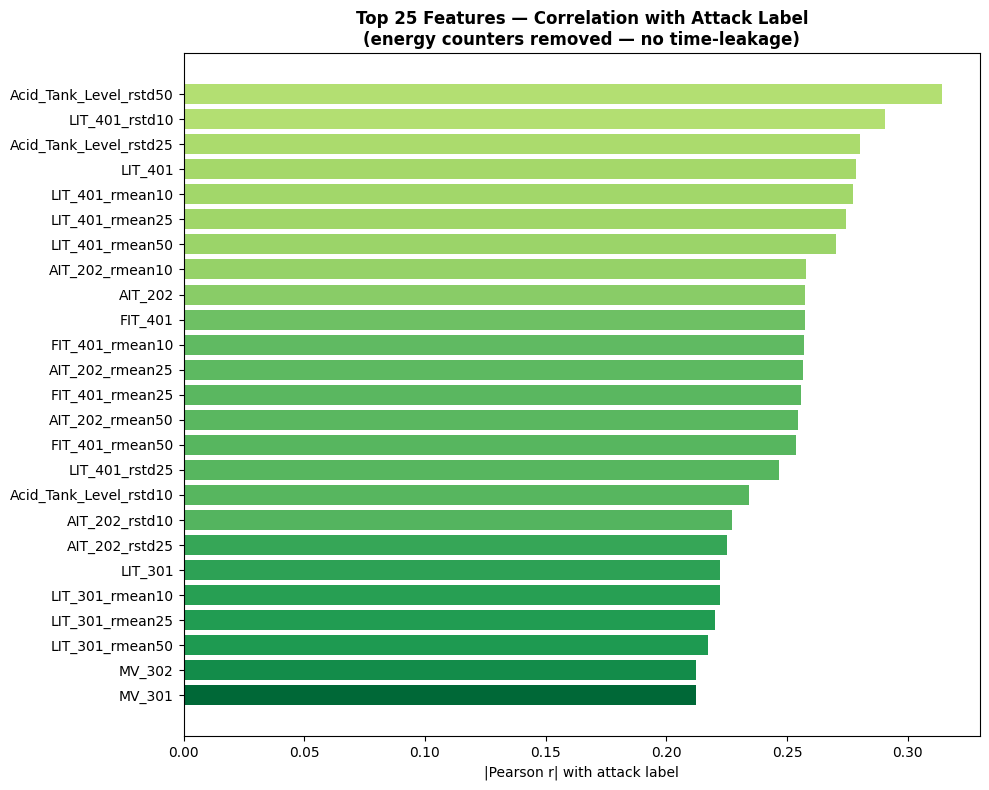

Top 10: {'Acid_Tank_Level_rstd50': 0.3143, 'LIT_401_rstd10': 0.2904, 'Acid_Tank_Level_rstd25': 0.2801, 'LIT_401': 0.2787, 'LIT_401_rmean10': 0.2773, 'LIT_401_rmean25': 0.2746, 'LIT_401_rmean50': 0.2704, 'AIT_202_rmean10': 0.2578, 'AIT_202': 0.2576, 'FIT_401': 0.2574}


In [35]:
# ── Correlation plot (no energy counters) ─────────────────────────────────────
corr_s = (pd.DataFrame(X_tr_sc, columns=FEATURE_COLS)
          .corrwith(pd.Series(yb_tr.astype(float)))
          .abs().sort_values(ascending=False))

top25 = corr_s.head(25)
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(top25.values / top25.values.max())
ax.barh(top25.index[::-1], top25.values[::-1], color=colors)
ax.set_xlabel("|Pearson r| with attack label")
ax.set_title("Top 25 Features — Correlation with Attack Label\n"
             "(energy counters removed — no time-leakage)", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR/"05_feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Top 10:", top25.head(10).round(4).to_dict())


## 6 · Run-Based Generalisation Test
Train on runs 1–3, test on run 4 (completely unseen).
This detects whether high accuracy is genuine or run-specific overfitting.


In [36]:
run_ids_all = df['run_id'].values

train_mask = np.isin(run_ids_all, [1, 2, 3])
X_run_tr   = X[train_mask];  y_run_tr = y[train_mask]
X_run_te   = X[~train_mask]; y_run_te = y[~train_mask]

sc_run = RobustScaler()
X_run_tr_sc = sc_run.fit_transform(X_run_tr)
X_run_te_sc = sc_run.transform(X_run_te)

assert np.isnan(X_run_tr_sc).sum() == 0

print(f"Run-based split: train={X_run_tr.shape[0]:,}  test(run4)={X_run_te.shape[0]:,}")

xgb_run = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=NUM_CLASSES,
    eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_run.fit(X_run_tr_sc, y_run_tr)
preds_run = xgb_run.predict(X_run_te_sc)

acc_run = accuracy_score(y_run_te, preds_run)
f1_run  = f1_score(y_run_te, preds_run, average='macro', zero_division=0)
print(f"\nRun-4 hold-out → Accuracy={acc_run:.4f}  Macro F1={f1_run:.4f}")
print()
labels_present = np.unique(np.concatenate([y_run_te, preds_run]))

print(classification_report(
    y_run_te,
    preds_run,
    labels=labels_present,
    target_names=[ATTACK_NAMES[i] for i in labels_present],
    digits=4,
    zero_division=0
))

if f1_run > 0.90:
    print("RESULT: Generalisation GOOD — model transfers to unseen run")
elif f1_run > 0.75:
    print("RESULT: Partial generalisation — some run-specific patterns present")
else:
    print("RESULT: Overfitting detected — review CUSUM / temporal features")


Run-based split: train=88,225  test(run4)=41,298

Run-4 hold-out → Accuracy=0.6375  Macro F1=0.2908

                           precision    recall  f1-score   support

         Normal Operation     0.7545    0.8667    0.8067     27589
     Tank Overflow Attack     0.0000    0.0000    0.0000         0
   pH Manipulation Attack     1.0000    0.9693    0.9844      1597
         Slow Ramp Attack     0.0194    0.0488    0.0277      2582
      Reconnaissance Scan     0.9060    0.2827    0.4309      2455
        Denial of Service     0.1626    0.0499    0.0764       941
            Replay Attack     0.0000    0.0000    0.0000      2392
Valve Manipulation Attack     0.0000    0.0000    0.0000      3742

                 accuracy                         0.6375     41298
                macro avg     0.3553    0.2772    0.2908     41298
             weighted avg     0.6015    0.6375    0.6061     41298

RESULT: Overfitting detected — review CUSUM / temporal features


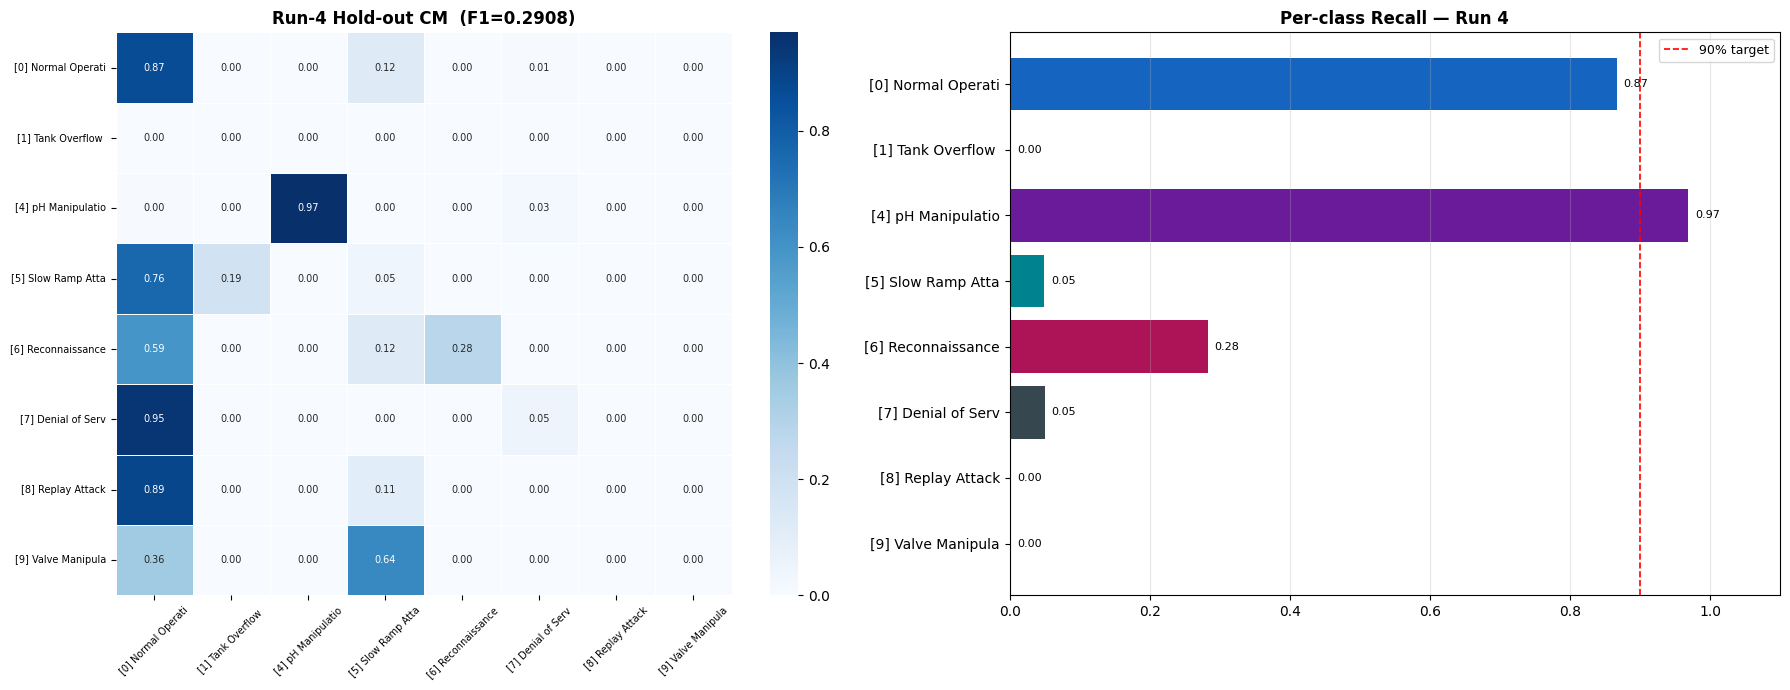

In [37]:
# ── Run-based confusion matrix ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Classes actually present in Run4
labels_present = np.unique(np.concatenate([y_run_te, preds_run]))

short = [f"[{i}] {ATTACK_NAMES[i][:14]}" for i in labels_present]

cm_run = confusion_matrix(
    y_run_te,
    preds_run,
    labels=labels_present,
    normalize='true'
)

sns.heatmap(
    cm_run,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=short,
    yticklabels=short,
    ax=axes[0],
    linewidths=0.4,
    annot_kws={'size':7}
)

axes[0].set_title(f"Run-4 Hold-out CM  (F1={f1_run:.4f})", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=7)

# ── Per-class recall bar ─────────────────────────────────────────

diag = cm_run.diagonal()

colors = [PALETTE[i] for i in labels_present]

axes[1].barh(
    short[::-1],
    diag[::-1],
    color=colors[::-1]
)

axes[1].axvline(0.9, color='red', ls='--', lw=1.2, label='90% target')
axes[1].set_xlim(0, 1.1)
axes[1].set_title("Per-class Recall — Run 4", fontweight='bold')
axes[1].legend(fontsize=9)

for i, v in enumerate(diag[::-1]):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=8)

axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_run_based_generalisation.png", dpi=150, bbox_inches='tight')
plt.show()

## 7 · Class Balancing — SMOTE + Class Weights

In [38]:
print("Before SMOTE:")
for c, n in sorted(Counter(y_tr).items()):
    print(f"  [{c}] {ATTACK_NAMES[c]:<35s} {n:>6,}")

smote = SMOTE(random_state=42, k_neighbors=3,
              sampling_strategy={2:4000, 3:4000, 7:4000})
X_bal, y_bal = smote.fit_resample(X_tr_sc, y_tr)
y_bin_bal    = (y_bal > 0).astype(np.int64)

print("\nAfter SMOTE:")
for c, n in sorted(Counter(y_bal).items()):
    print(f"  [{c}] {ATTACK_NAMES[c]:<35s} {n:>6,}")
print(f"\nTotal training: {len(X_bal):,}")

# Class weights
cw_mc  = dict(zip(*(lambda a,b: (a.tolist(),b.tolist()))(
    *[compute_class_weight('balanced', classes=np.unique(y_bal), y=y_bal)][::-1],
    *[np.unique(y_bal)][::-1])))
cw_mc  = dict(zip(np.unique(y_bal).tolist(),
                  compute_class_weight('balanced', classes=np.unique(y_bal), y=y_bal).tolist()))
cw_bin = dict(zip([0,1], compute_class_weight('balanced', classes=np.array([0,1]), y=y_bin_bal).tolist()))
print(f"\nBinary weights: {cw_bin}")


Before SMOTE:
  [0] Normal Operation                    71,885
  [1] Tank Overflow Attack                 3,800
  [2] Chemical Depletion Attack            1,259
  [3] Membrane Damage Attack               1,964
  [4] pH Manipulation Attack               4,346
  [5] Slow Ramp Attack                     4,991
  [6] Reconnaissance Scan                  5,002
  [7] Denial of Service                    1,521
  [8] Replay Attack                        3,956
  [9] Valve Manipulation Attack            4,894

After SMOTE:
  [0] Normal Operation                    71,885
  [1] Tank Overflow Attack                 3,800
  [2] Chemical Depletion Attack            4,000
  [3] Membrane Damage Attack               4,000
  [4] pH Manipulation Attack               4,346
  [5] Slow Ramp Attack                     4,991
  [6] Reconnaissance Scan                  5,002
  [7] Denial of Service                    4,000
  [8] Replay Attack                        3,956
  [9] Valve Manipulation Attack          

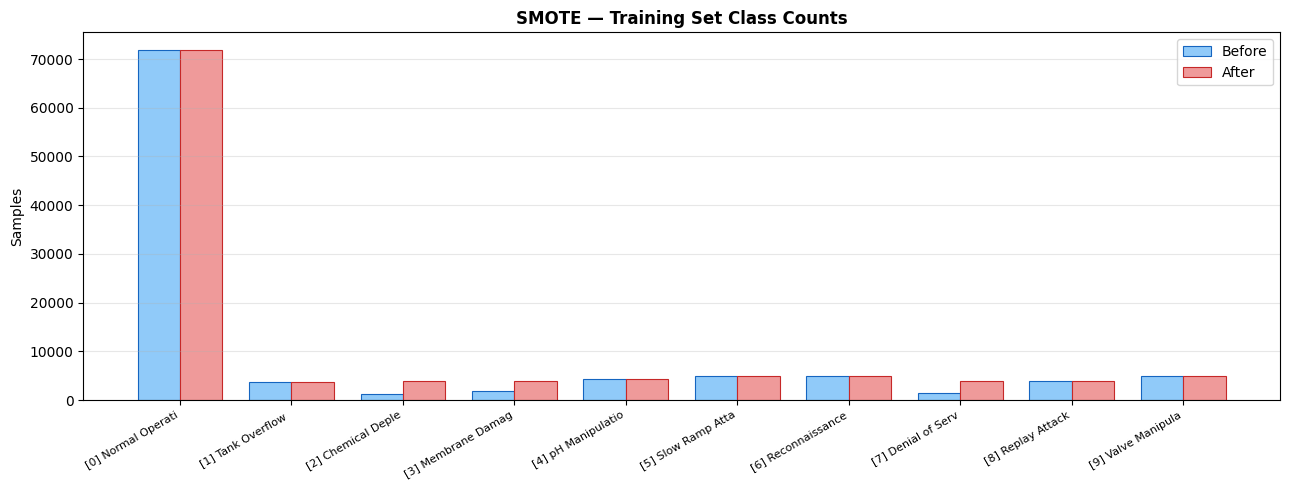

In [39]:
# ── SMOTE balance plot ────────────────────────────────────────────────────────
before = Counter(y_tr)
after  = Counter(y_bal)
x = np.arange(NUM_CLASSES)
w = 0.38
fig, ax = plt.subplots(figsize=(13,5))
ax.bar(x-w/2, [before.get(i,0) for i in range(NUM_CLASSES)], w,
       label='Before', color='#90CAF9', edgecolor='#1565C0', lw=0.8)
ax.bar(x+w/2, [after.get(i,0)  for i in range(NUM_CLASSES)], w,
       label='After',  color='#EF9A9A', edgecolor='#C62828', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"[{i}] {ATTACK_NAMES[i][:14]}" for i in range(NUM_CLASSES)],
                   rotation=30, ha='right', fontsize=8)
ax.set_title("SMOTE — Training Set Class Counts", fontweight='bold')
ax.set_ylabel("Samples"); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"07_smote.png", dpi=150, bbox_inches='tight')
plt.show()


## 8 · Classical ML — Binary Detection

In [40]:
def fit_eval(model, Xtr, ytr, Xte, yte, name, labels=None, save_as=None):
    print(f"\nFitting {name}...")
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)
    acc   = accuracy_score(yte, ypred)
    f1    = f1_score(yte, ypred, average='macro', zero_division=0)
    print(f"  Accuracy : {acc:.4f}   Macro F1 : {f1:.4f}")
    if labels:
        print(classification_report(yte, ypred, target_names=labels, digits=4))
    if save_as:
        joblib.dump(model, MODELS_DIR/save_as)
        print(f"  Saved: {save_as}")
    return {'model':model,'name':name,'acc':acc,'f1':f1,'y_pred':ypred,'y_true':yte}

BIN = ["Normal","Attack"]


In [41]:
# Random Forest Binary
rf_bin = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, class_weight=cw_bin, n_jobs=-1, random_state=42)
r_rf_bin = fit_eval(rf_bin, X_bal, y_bin_bal, X_te_sc, yb_te,
                    "Random Forest (Binary)", BIN, "rf_binary.joblib")



Fitting Random Forest (Binary)...
  Accuracy : 0.8948   Macro F1 : 0.8756
              precision    recall  f1-score   support

      Normal     0.9208    0.9282    0.9245     17972
      Attack     0.8343    0.8192    0.8267      7933

    accuracy                         0.8948     25905
   macro avg     0.8776    0.8737    0.8756     25905
weighted avg     0.8943    0.8948    0.8945     25905

  Saved: rf_binary.joblib


In [42]:
# XGBoost Binary
scale_pos = float(np.sum(y_bin_bal==0)/np.sum(y_bin_bal==1))
xgb_bin = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=42, n_jobs=-1)
r_xgb_bin = fit_eval(xgb_bin, X_bal, y_bin_bal, X_te_sc, yb_te,
                     "XGBoost (Binary)", BIN, "xgb_binary.joblib")



Fitting XGBoost (Binary)...
  Accuracy : 0.9072   Macro F1 : 0.8946
              precision    recall  f1-score   support

      Normal     0.9606    0.9033    0.9311     17972
      Attack     0.8070    0.9160    0.8581      7933

    accuracy                         0.9072     25905
   macro avg     0.8838    0.9097    0.8946     25905
weighted avg     0.9136    0.9072    0.9087     25905

  Saved: xgb_binary.joblib


In [43]:
# SVM Binary — subsample (SVM is O(n²))
idx = np.random.RandomState(42).choice(len(X_bal), min(30_000,len(X_bal)), replace=False)
svm_bin = SVC(kernel='rbf', C=10, gamma='scale', class_weight=cw_bin,
              probability=True, random_state=42)
r_svm_bin = fit_eval(svm_bin, X_bal[idx], y_bin_bal[idx], X_te_sc, yb_te,
                     "SVM RBF (Binary)", BIN, "svm_binary.joblib")



Fitting SVM RBF (Binary)...
  Accuracy : 0.8894   Macro F1 : 0.8561
              precision    recall  f1-score   support

      Normal     0.8704    0.9878    0.9254     17972
      Attack     0.9601    0.6667    0.7869      7933

    accuracy                         0.8894     25905
   macro avg     0.9152    0.8272    0.8561     25905
weighted avg     0.8978    0.8894    0.8830     25905

  Saved: svm_binary.joblib


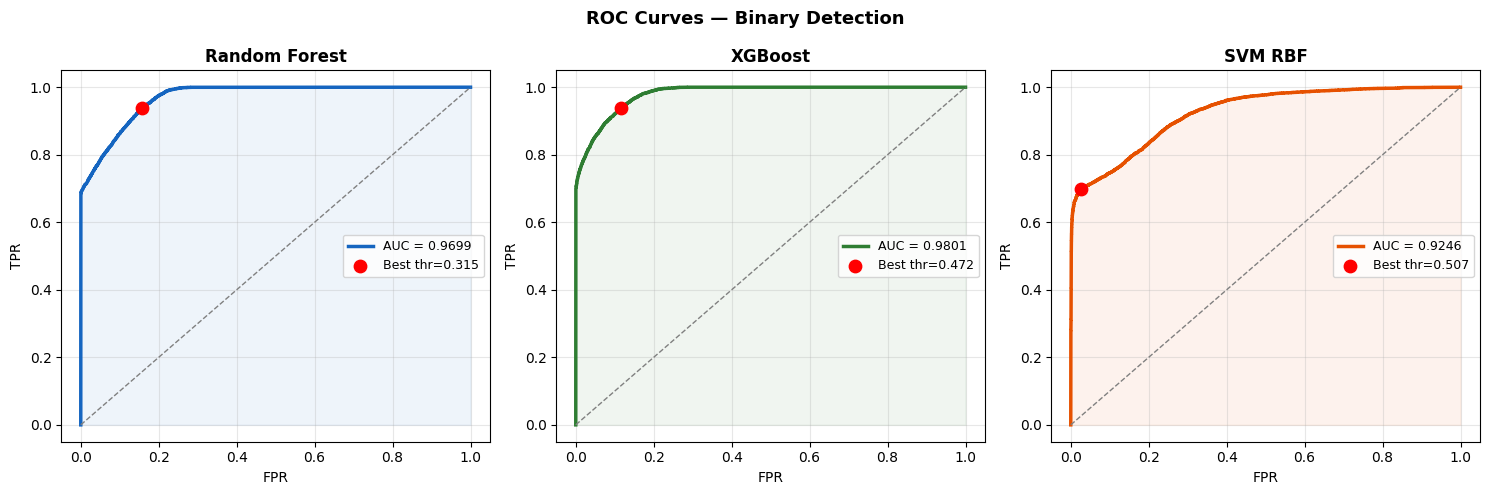

In [44]:
# ── Binary ROC curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (mdl, name, col) in zip(axes, [
    (rf_bin,  "Random Forest", '#1565C0'),
    (xgb_bin, "XGBoost",       '#2E7D32'),
    (svm_bin, "SVM RBF",       '#E65100'),
]):
    proba = mdl.predict_proba(X_te_sc)[:,1]
    fpr, tpr, thr = roc_curve(yb_te, proba)
    auc = roc_auc_score(yb_te, proba)
    ax.plot(fpr, tpr, lw=2.5, color=col, label=f"AUC = {auc:.4f}")
    ax.plot([0,1],[0,1],'--',color='grey',lw=1)
    j = np.argmax(tpr - fpr)
    ax.scatter(fpr[j], tpr[j], s=80, color='red', zorder=5,
               label=f"Best thr={thr[j]:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.07, color=col)
    ax.set_title(name, fontweight='bold'); ax.legend(fontsize=9)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.grid(alpha=0.3)
plt.suptitle("ROC Curves — Binary Detection", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"08_roc_binary.png", dpi=150, bbox_inches='tight')
plt.show()


## 9 · Classical ML — Multi-Class (10 Classes)

In [45]:
MC_LABELS = [ATTACK_NAMES[i] for i in range(NUM_CLASSES)]

# Random Forest Multi-class
rf_mc = RandomForestClassifier(
    n_estimators=400, min_samples_leaf=1, class_weight=cw_mc, n_jobs=-1, random_state=42)
r_rf_mc = fit_eval(rf_mc, X_bal, y_bal, X_te_sc, y_te,
                   "Random Forest (Multi-class)", MC_LABELS, "rf_multiclass.joblib")



Fitting Random Forest (Multi-class)...
  Accuracy : 0.8944   Macro F1 : 0.7604
                           precision    recall  f1-score   support

         Normal Operation     0.8950    0.9694    0.9307     17972
     Tank Overflow Attack     1.0000    1.0000    1.0000       950
Chemical Depletion Attack     1.0000    1.0000    1.0000       315
   Membrane Damage Attack     1.0000    0.9980    0.9990       491
   pH Manipulation Attack     1.0000    1.0000    1.0000      1087
         Slow Ramp Attack     1.0000    0.9992    0.9996      1248
      Reconnaissance Scan     0.6178    0.2832    0.3884      1250
        Denial of Service     0.3198    0.1868    0.2359       380
            Replay Attack     0.1278    0.0465    0.0682       989
Valve Manipulation Attack     0.9941    0.9714    0.9826      1223

                 accuracy                         0.8944     25905
                macro avg     0.7955    0.7454    0.7604     25905
             weighted avg     0.8652    0.8944 

In [46]:
# XGBoost Multi-class
xgb_mc = xgb.XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=NUM_CLASSES,
    eval_metric='mlogloss', random_state=42, n_jobs=-1)
r_xgb_mc = fit_eval(xgb_mc, X_bal, y_bal, X_te_sc, y_te,
                    "XGBoost (Multi-class)", MC_LABELS, "xgb_multiclass.joblib")



Fitting XGBoost (Multi-class)...
  Accuracy : 0.9429   Macro F1 : 0.8807
                           precision    recall  f1-score   support

         Normal Operation     0.9271    0.9969    0.9607     17972
     Tank Overflow Attack     1.0000    1.0000    1.0000       950
Chemical Depletion Attack     1.0000    1.0000    1.0000       315
   Membrane Damage Attack     0.9959    0.9939    0.9949       491
   pH Manipulation Attack     1.0000    1.0000    1.0000      1087
         Slow Ramp Attack     1.0000    0.9984    0.9992      1248
      Reconnaissance Scan     0.9648    0.6144    0.7507      1250
        Denial of Service     0.9206    0.6711    0.7763       380
            Replay Attack     0.9312    0.2053    0.3364       989
Valve Manipulation Attack     0.9975    0.9804    0.9889      1223

                 accuracy                         0.9429     25905
                macro avg     0.9737    0.8460    0.8807     25905
             weighted avg     0.9438    0.9429    0.9

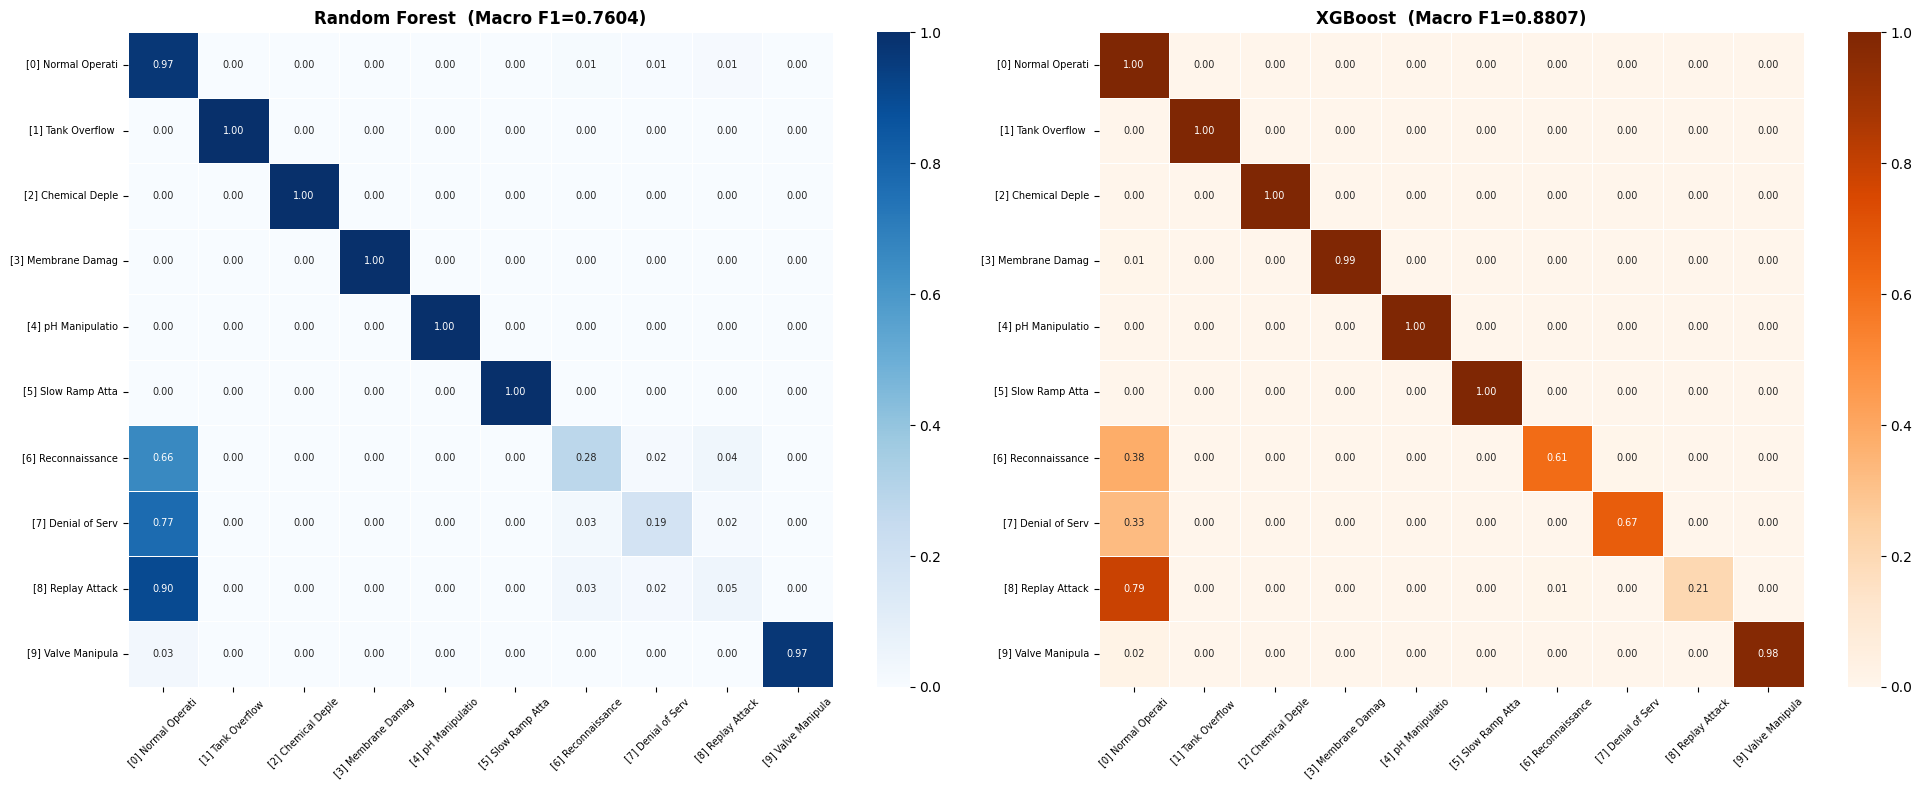

In [47]:
# ── Confusion matrices ────────────────────────────────────────────────────────
short = [f"[{i}] {ATTACK_NAMES[i][:14]}" for i in range(NUM_CLASSES)]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, res, cmap_, title in zip(axes,
    [r_rf_mc, r_xgb_mc],
    ['Blues','Oranges'],
    ['Random Forest','XGBoost']):
    cm = confusion_matrix(res['y_true'], res['y_pred'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap_,
                xticklabels=short, yticklabels=short,
                ax=ax, linewidths=0.4, annot_kws={'size':7})
    ax.set_title(f"{title}  (Macro F1={res['f1']:.4f})", fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"09_cm_mc.png", dpi=150, bbox_inches='tight')
plt.show()


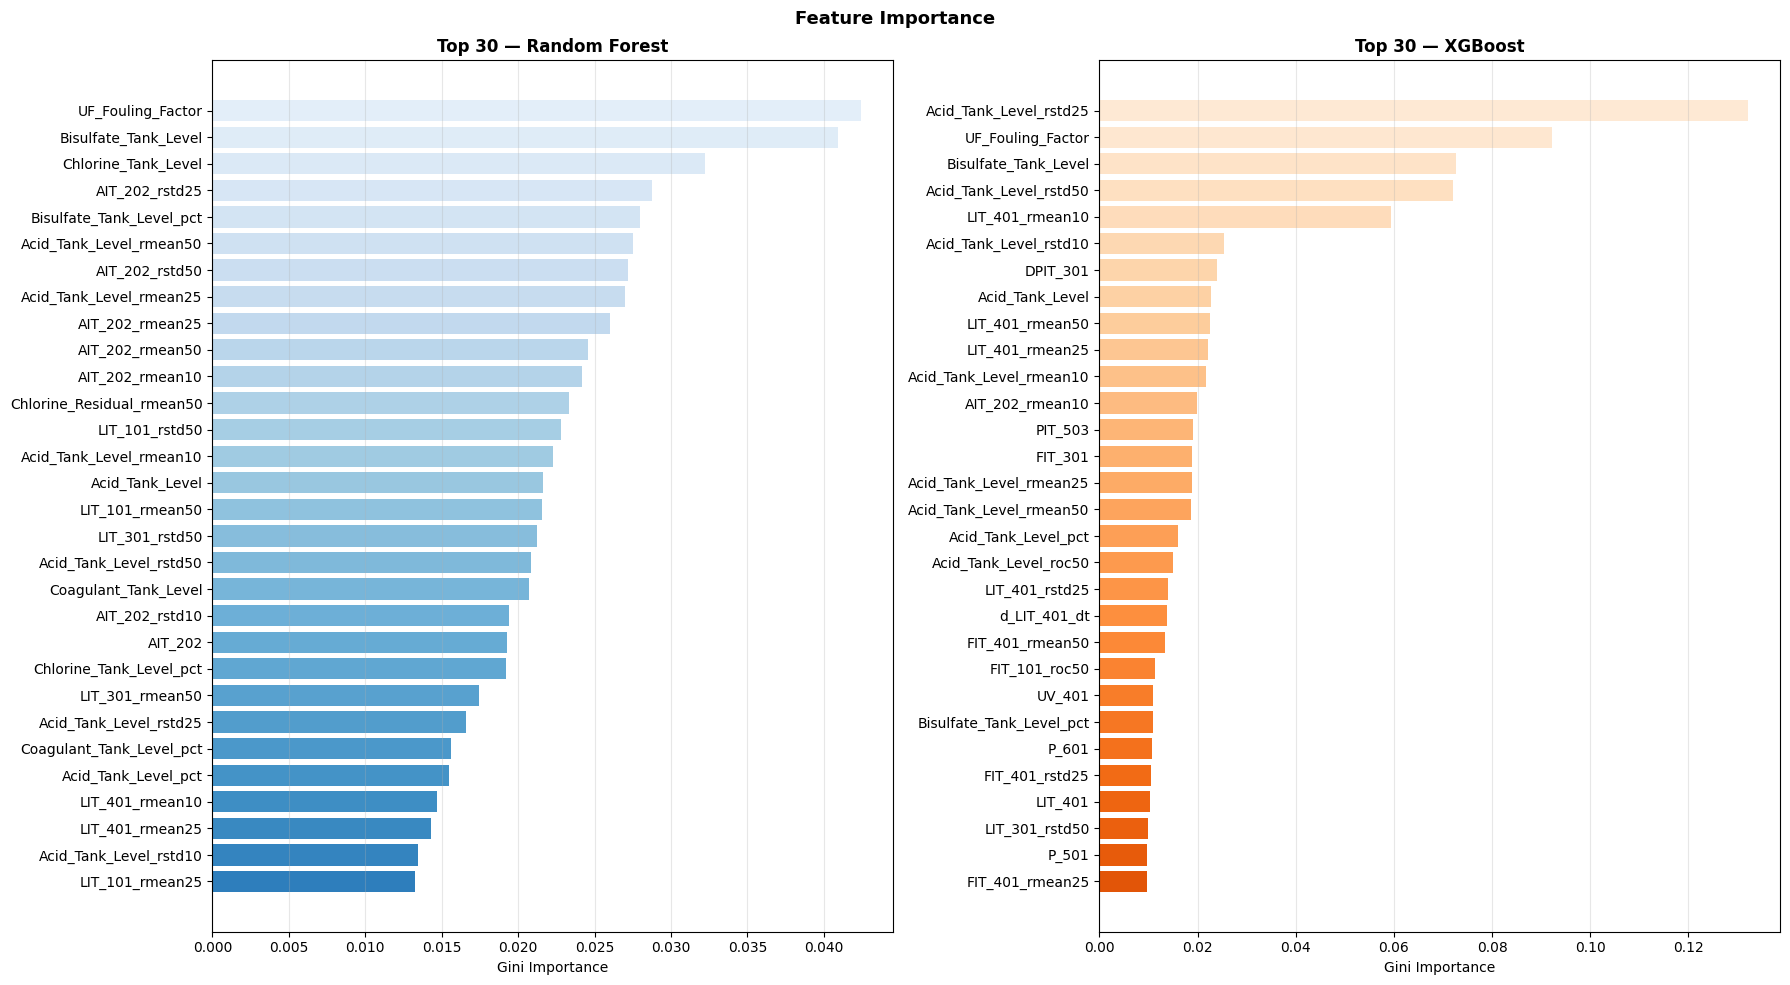

In [48]:
# ── Feature importance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
for ax, imp_arr, name, cmap_ in [
    (axes[0], rf_mc.feature_importances_,  "Random Forest", 'Blues_r'),
    (axes[1], xgb_mc.feature_importances_, "XGBoost",       'Oranges_r'),
]:
    imp = pd.Series(imp_arr, index=FEATURE_COLS).sort_values(ascending=False).head(30)
    ax.barh(imp.index[::-1], imp.values[::-1],
            color=plt.cm.get_cmap(cmap_)(np.linspace(0.3,0.9,30)))
    ax.set_title(f"Top 30 — {name}", fontweight='bold')
    ax.set_xlabel("Gini Importance")
    ax.grid(axis='x', alpha=0.3)
plt.suptitle("Feature Importance", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"10_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()


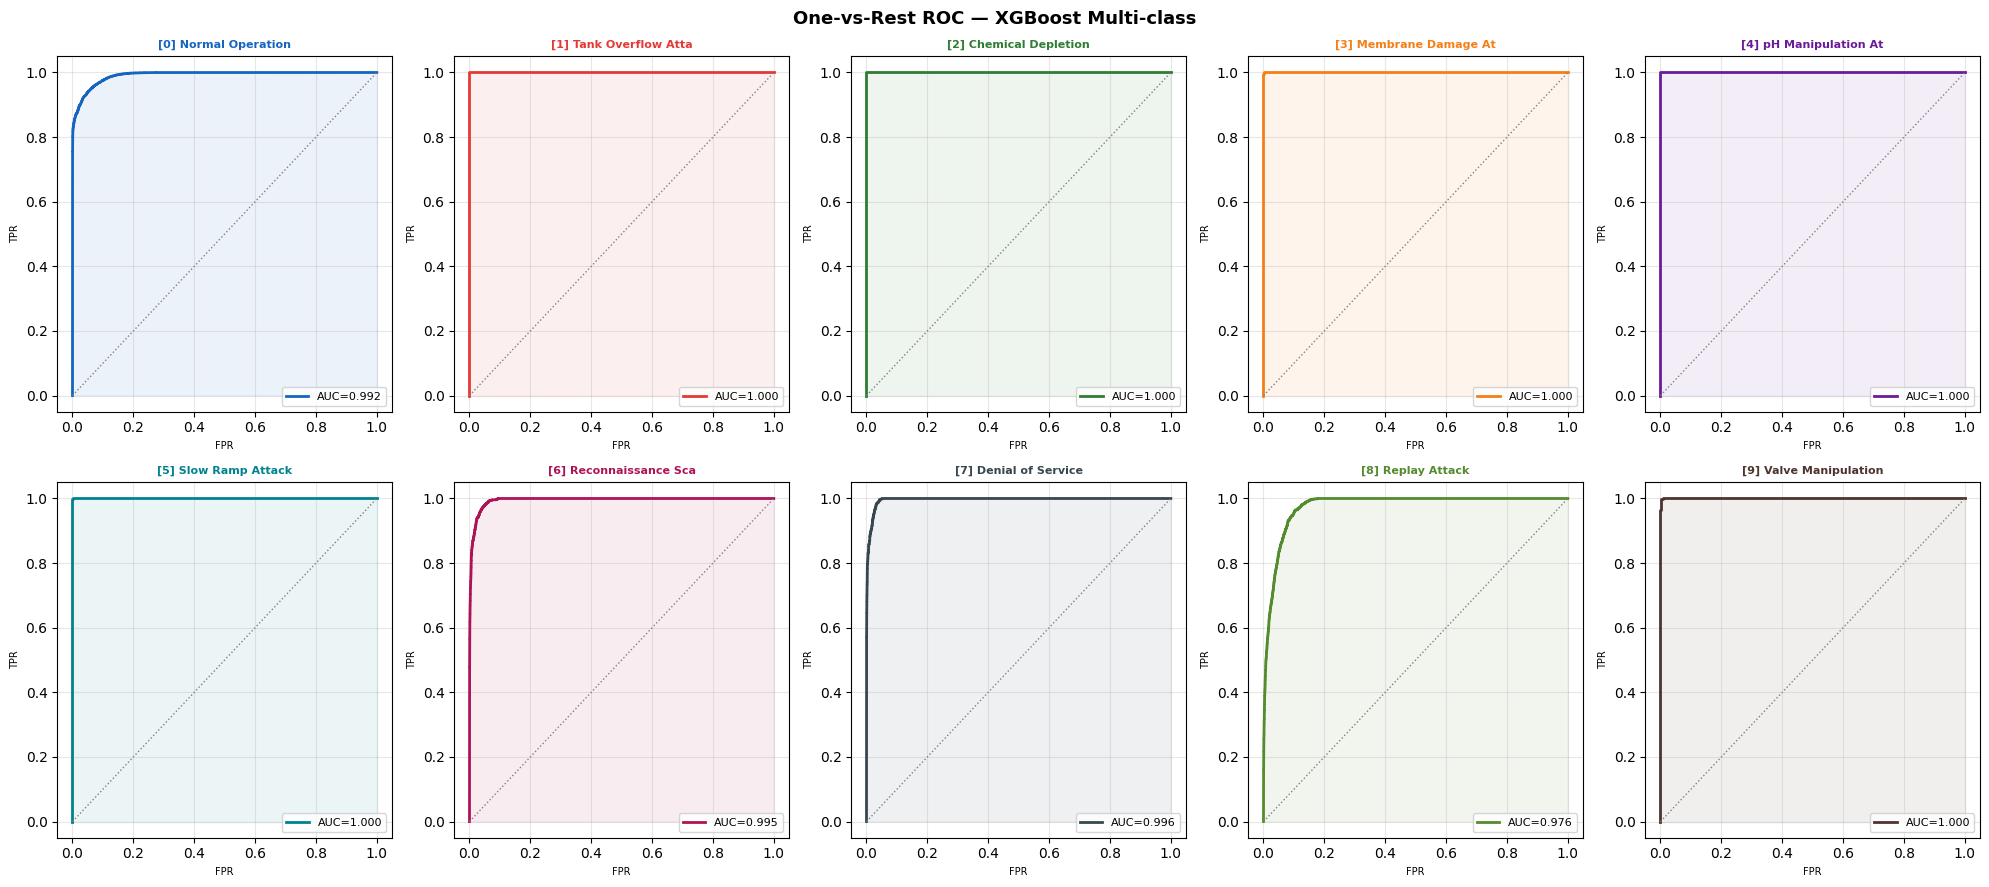

In [49]:
# ── Multi-class ROC ───────────────────────────────────────────────────────────
y_ohe   = label_binarize(y_te, classes=list(range(NUM_CLASSES)))
xgb_prb = xgb_mc.predict_proba(X_te_sc)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
for i, ax in enumerate(axes.flat):
    fpr, tpr, _ = roc_curve(y_ohe[:,i], xgb_prb[:,i])
    auc = roc_auc_score(y_ohe[:,i], xgb_prb[:,i])
    ax.plot(fpr, tpr, lw=2, color=PALETTE[i], label=f"AUC={auc:.3f}")
    ax.plot([0,1],[0,1],':', color='grey', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color=PALETTE[i])
    ax.set_title(f"[{i}] {ATTACK_NAMES[i][:18]}", fontsize=8,
                 fontweight='bold', color=PALETTE[i])
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlabel("FPR",fontsize=7); ax.set_ylabel("TPR",fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("One-vs-Rest ROC — XGBoost Multi-class", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"11_roc_mc.png", dpi=150, bbox_inches='tight')
plt.show()


## 10 · MLP Neural Network

In [50]:
class SWaTMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)
    def predict_proba(self, Xnp):
        self.eval()
        with torch.no_grad():
            return torch.softmax(
                self.net(torch.FloatTensor(Xnp).to(next(self.parameters()).device)),
                dim=1).cpu().numpy()

INPUT_DIM = X_bal.shape[1]
mlp_mc  = SWaTMLP(INPUT_DIM, [512,256,128,64], NUM_CLASSES, dropout=0.3).to(DEVICE)
mlp_bin = SWaTMLP(INPUT_DIM, [256,128,64],      2,           dropout=0.25).to(DEVICE)
print(f"MLP multi-class params : {sum(p.numel() for p in mlp_mc.parameters()):,}")
print(f"MLP binary params      : {sum(p.numel() for p in mlp_bin.parameters()):,}")


MLP multi-class params : 244,170
MLP binary params      : 76,738


In [51]:
def make_loaders(Xtr, ytr, Xte, yte, batch=1024):
    tr = DataLoader(TensorDataset(torch.FloatTensor(Xtr), torch.LongTensor(ytr)),
                    batch_size=batch, shuffle=True,  num_workers=0)
    te = DataLoader(TensorDataset(torch.FloatTensor(Xte), torch.LongTensor(yte)),
                    batch_size=batch, shuffle=False, num_workers=0)
    return tr, te

def train_epoch(model, loader, crit, opt, device):
    model.train()
    tl, tc, tn = 0., 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(Xb); loss = crit(out, yb)
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.); opt.step()
        tl += loss.item()*len(yb); tc += (out.argmax(1)==yb).sum().item(); tn += len(yb)
    return tl/tn, tc/tn

def eval_epoch(model, loader, crit, device):
    model.eval(); vl, vc, vn = 0., 0, 0; pa, ta = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = model(Xb); vl += crit(out, yb).item()*len(yb)
            p = out.argmax(1); vc += (p==yb).sum().item(); vn += len(yb)
            pa.extend(p.cpu().numpy()); ta.extend(yb.cpu().numpy())
    vf = f1_score(ta, pa, average='macro', zero_division=0)
    return vl/vn, vc/vn, vf, np.array(pa)


In [52]:
# ── MLP multi-class training ──────────────────────────────────────────────────
tr_mc, te_mc = make_loaders(X_bal, y_bal, X_te_sc, y_te)
cw_t  = torch.FloatTensor([cw_mc.get(i,1.) for i in range(NUM_CLASSES)]).to(DEVICE)
crit_mc = nn.CrossEntropyLoss(weight=cw_t)
opt_mc  = torch.optim.Adam(mlp_mc.parameters(), lr=1e-3, weight_decay=1e-5)
# FIX: removed verbose= argument (removed in PyTorch >= 2.2)
sched_mc = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_mc, patience=5, factor=0.5)

EPOCHS_MC = 50
best_f1_mc, best_preds_mc = 0., None
hist_mc = {'tr_loss':[],'va_loss':[],'tr_acc':[],'va_acc':[],'va_f1':[]}

print(f"Training MLP multi-class — {EPOCHS_MC} epochs on {DEVICE}")
print(f"{'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}")
print("─"*52)
for ep in range(1, EPOCHS_MC+1):
    tl, ta = train_epoch(mlp_mc, tr_mc, crit_mc, opt_mc, DEVICE)
    vl, va, vf, preds = eval_epoch(mlp_mc, te_mc, crit_mc, DEVICE)
    sched_mc.step(vl)
    for k,v in zip(['tr_loss','va_loss','tr_acc','va_acc','va_f1'],[tl,vl,ta,va,vf]):
        hist_mc[k].append(v)
    if vf > best_f1_mc:
        best_f1_mc, best_preds_mc = vf, preds.copy()
        torch.save(mlp_mc.state_dict(), MODELS_DIR/"mlp_multiclass_best.pt")
    if ep%5==0 or ep==1:
        print(f"{ep:>4}  {tl:>8.4f}  {ta:>7.4f}  {vl:>8.4f}  {va:>7.4f}  {vf:>7.4f}")

print(f"\nBest MLP Macro F1: {best_f1_mc:.4f}  — saved: mlp_multiclass_best.pt")


Training MLP multi-class — 50 epochs on cpu
  Ep    TrLoss    TrAcc    VaLoss    VaAcc     VaF1
────────────────────────────────────────────────────
   1    0.9854   0.4045    0.5937   0.6837   0.6699
   5    0.4220   0.7480    0.4254   0.7417   0.7300
  10    0.3838   0.7602    0.3810   0.7489   0.7419
  15    0.3624   0.7674    0.3599   0.7551   0.7469
  20    0.3558   0.7659    0.3502   0.7600   0.7533
  25    0.3464   0.7701    0.3478   0.7586   0.7522
  30    0.3383   0.7745    0.3461   0.7606   0.7507
  35    0.3314   0.7738    0.3350   0.7669   0.7581
  40    0.3307   0.7761    0.3238   0.7710   0.7626
  45    0.3217   0.7786    0.3305   0.7669   0.7591
  50    0.3024   0.7856    0.3191   0.7721   0.7662

Best MLP Macro F1: 0.7689  — saved: mlp_multiclass_best.pt


In [53]:
# ── MLP binary training ───────────────────────────────────────────────────────
tr_bin, te_bin = make_loaders(X_bal, y_bin_bal, X_te_sc, yb_te)
cw_bt   = torch.FloatTensor([cw_bin[0], cw_bin[1]]).to(DEVICE)
crit_bin = nn.CrossEntropyLoss(weight=cw_bt)
opt_bin  = torch.optim.Adam(mlp_bin.parameters(), lr=1e-3, weight_decay=1e-5)
# FIX: no verbose= argument
sched_bin = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_bin, patience=5, factor=0.5)

EPOCHS_BIN = 30
best_f1_bin, best_preds_bin = 0., None
print(f"Training MLP binary — {EPOCHS_BIN} epochs")
for ep in range(1, EPOCHS_BIN+1):
    tl, ta = train_epoch(mlp_bin, tr_bin, crit_bin, opt_bin, DEVICE)
    vl, va, vf, preds = eval_epoch(mlp_bin, te_bin, crit_bin, DEVICE)
    sched_bin.step(vl)
    if vf > best_f1_bin:
        best_f1_bin, best_preds_bin = vf, preds.copy()
        torch.save(mlp_bin.state_dict(), MODELS_DIR/"mlp_binary_best.pt")
    if ep%5==0 or ep==1:
        print(f"  Ep {ep:3d}  TrAcc={ta:.4f}  VaAcc={va:.4f}  VaF1={vf:.4f}")

print(f"\nBest Binary MLP F1: {best_f1_bin:.4f}")
print(classification_report(yb_te, best_preds_bin, target_names=["Normal","Attack"], digits=4))


Training MLP binary — 30 epochs
  Ep   1  TrAcc=0.8301  VaAcc=0.8397  VaF1=0.8252
  Ep   5  TrAcc=0.8512  VaAcc=0.8386  VaF1=0.8276
  Ep  10  TrAcc=0.8545  VaAcc=0.8467  VaF1=0.8349
  Ep  15  TrAcc=0.8622  VaAcc=0.8547  VaF1=0.8416
  Ep  20  TrAcc=0.8678  VaAcc=0.8639  VaF1=0.8506
  Ep  25  TrAcc=0.8709  VaAcc=0.8706  VaF1=0.8573
  Ep  30  TrAcc=0.8778  VaAcc=0.8742  VaF1=0.8606

Best Binary MLP F1: 0.8618
              precision    recall  f1-score   support

      Normal     0.9523    0.8650    0.9065     17972
      Attack     0.7467    0.9019    0.8170      7933

    accuracy                         0.8763     25905
   macro avg     0.8495    0.8834    0.8618     25905
weighted avg     0.8894    0.8763    0.8791     25905



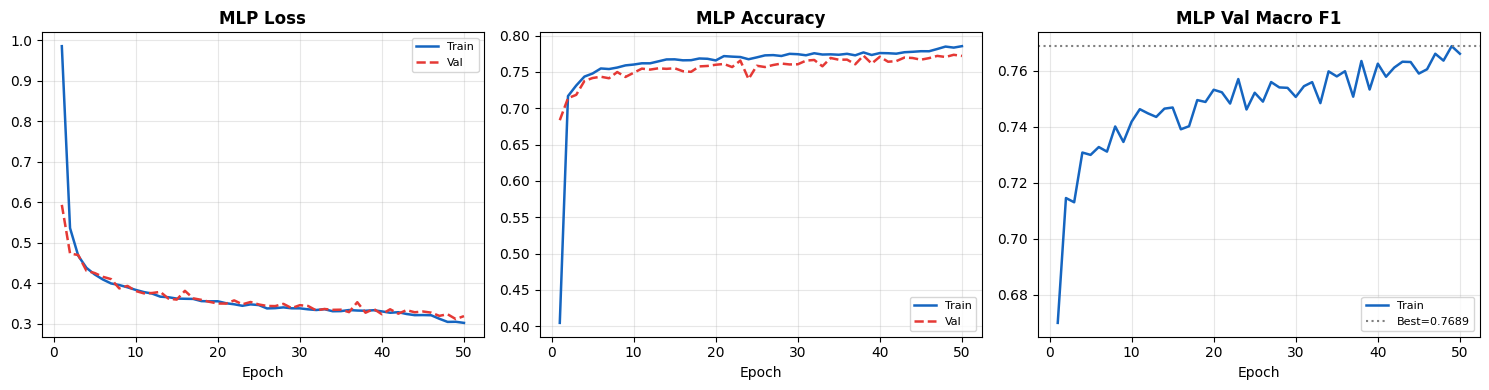

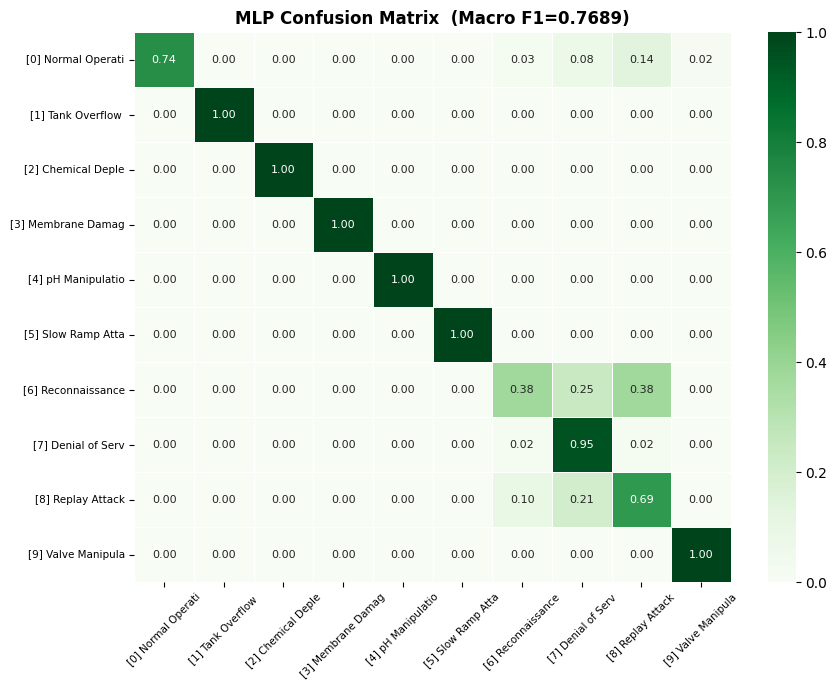

                           precision    recall  f1-score   support

         Normal Operation     0.9997    0.7354    0.8474     17972
     Tank Overflow Attack     0.9927    1.0000    0.9963       950
Chemical Depletion Attack     1.0000    1.0000    1.0000       315
   Membrane Damage Attack     1.0000    1.0000    1.0000       491
   pH Manipulation Attack     0.9982    1.0000    0.9991      1087
         Slow Ramp Attack     0.9960    0.9992    0.9976      1248
      Reconnaissance Scan     0.4404    0.3752    0.4052      1250
        Denial of Service     0.1558    0.9500    0.2677       380
            Replay Attack     0.1876    0.6916    0.2951       989
Valve Manipulation Attack     0.7872    0.9984    0.8803      1223

                 accuracy                         0.7737     25905
                macro avg     0.7558    0.8750    0.7689     25905
             weighted avg     0.9188    0.7737    0.8219     25905



In [54]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep_x = range(1, EPOCHS_MC+1)
for ax, tk, vk, title in [
    (axes[0], 'tr_loss', 'va_loss', 'Loss'),
    (axes[1], 'tr_acc',  'va_acc',  'Accuracy'),
    (axes[2], 'va_f1',   None,      'Val Macro F1'),
]:
    ax.plot(ep_x, hist_mc[tk], color='#1565C0', label='Train', lw=1.8)
    if vk: ax.plot(ep_x, hist_mc[vk], color='#E53935', label='Val', lw=1.8, ls='--')
    if title == 'Val Macro F1':
        ax.axhline(best_f1_mc, color='grey', ls=':', label=f'Best={best_f1_mc:.4f}')
    ax.set_title(f"MLP {title}", fontweight='bold'); ax.legend(fontsize=8)
    ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"12_mlp_training.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9,7))
cm = confusion_matrix(y_te, best_preds_mc, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=short, yticklabels=short,
            ax=ax, linewidths=0.4, annot_kws={'size':8})
ax.set_title(f"MLP Confusion Matrix  (Macro F1={best_f1_mc:.4f})", fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7.5)
ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"12_mlp_cm.png", dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_te, best_preds_mc, target_names=MC_LABELS, digits=4))


## 11 · BiLSTM + Attention

In [55]:
SEQ_LEN  = 25
SEQ_STEP = 5

def build_sequences(X_full, y_full, run_ids, seq_len=25, step=5):
    Xs, ys = [], []
    for rid in np.unique(run_ids):
        m  = run_ids == rid
        Xr, yr = X_full[m], y_full[m]
        for i in range(0, len(Xr)-seq_len, step):
            Xs.append(Xr[i:i+seq_len]); ys.append(yr[i+seq_len-1])
    return np.array(Xs,dtype=np.float32), np.array(ys,dtype=np.int64)

X_full_sc   = scaler.transform(X)
run_ids_all = df['run_id'].values
assert np.isnan(X_full_sc).sum() == 0

print("Building sequences...")
X_seq, y_seq = build_sequences(X_full_sc, y, run_ids_all, SEQ_LEN, SEQ_STEP)
print(f"Sequences: {X_seq.shape}")

X_sq_tr, X_sq_te, y_sq_tr, y_sq_te = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
print(f"LSTM train: {X_sq_tr.shape}  test: {X_sq_te.shape}")


Building sequences...
Sequences: (25881, 25, 134)
LSTM train: (20704, 25, 134)  test: (5177, 25, 134)


In [56]:
class SWaTLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 dropout=0.3, bidirectional=True):
        super().__init__()
        self.D = 2 if bidirectional else 1
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0,
                            bidirectional=bidirectional)
        self.attn = nn.Linear(hidden_dim*self.D, 1)
        self.norm = nn.LayerNorm(hidden_dim*self.D)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim*self.D, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        w   = torch.softmax(self.attn(out), dim=1)
        ctx = (w*out).sum(dim=1)
        return self.fc(self.drop(self.norm(ctx)))

lstm_model = SWaTLSTM(X_sq_tr.shape[2], 128, 2, NUM_CLASSES).to(DEVICE)
print(f"LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}")


LSTM params: 668,939


In [57]:
# SMOTE on flattened sequences
B, T, F = X_sq_tr.shape
smote_sq = SMOTE(random_state=42, k_neighbors=3,
                 sampling_strategy={2:4000, 3:4000, 7:4000})
X_sq_flat_bal, y_sq_bal = smote_sq.fit_resample(X_sq_tr.reshape(B, T*F), y_sq_tr)
X_sq_tr_bal = X_sq_flat_bal.reshape(-1, T, F).astype(np.float32)
print(f"LSTM balanced train: {X_sq_tr_bal.shape}")

lstm_tr, lstm_te = make_loaders(X_sq_tr_bal, y_sq_bal, X_sq_te, y_sq_te, batch=512)

sq_cw   = compute_class_weight('balanced', classes=np.unique(y_sq_bal), y=y_sq_bal)
sq_cw_t = torch.FloatTensor([dict(zip(np.unique(y_sq_bal),sq_cw)).get(i,1.)
                              for i in range(NUM_CLASSES)]).to(DEVICE)
lstm_crit  = nn.CrossEntropyLoss(weight=sq_cw_t)
lstm_opt   = torch.optim.AdamW(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)
# FIX: no verbose= argument
lstm_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(lstm_opt, patience=5, factor=0.5)


LSTM balanced train: (31755, 25, 134)


In [58]:
LSTM_EPOCHS = 40
best_f1_lstm, best_preds_lstm = 0., None
lstm_hist = {'tr_loss':[],'va_loss':[],'va_f1':[]}

print(f"Training BiLSTM — {LSTM_EPOCHS} epochs on {DEVICE}")
print(f"{'Ep':>4}  {'TrLoss':>8}  {'VaLoss':>8}  {'VaF1':>7}")
print("─"*36)
for ep in range(1, LSTM_EPOCHS+1):
    tl, _ = train_epoch(lstm_model, lstm_tr, lstm_crit, lstm_opt, DEVICE)
    vl, _, vf, preds = eval_epoch(lstm_model, lstm_te, lstm_crit, DEVICE)
    lstm_sched.step(vl)
    lstm_hist['tr_loss'].append(tl); lstm_hist['va_loss'].append(vl)
    lstm_hist['va_f1'].append(vf)
    if vf > best_f1_lstm:
        best_f1_lstm, best_preds_lstm = vf, preds.copy()
        torch.save(lstm_model.state_dict(), MODELS_DIR/"lstm_best.pt")
    if ep%5==0 or ep==1:
        print(f"{ep:>4}  {tl:>8.4f}  {vl:>8.4f}  {vf:>7.4f}")

print(f"\nBest BiLSTM F1: {best_f1_lstm:.4f}  — saved: lstm_best.pt")
print(classification_report(y_sq_te, best_preds_lstm, target_names=MC_LABELS, digits=4))


Training BiLSTM — 40 epochs on cpu
  Ep    TrLoss    VaLoss     VaF1
────────────────────────────────────
   1    0.6789    0.5920   0.7085
   5    0.3695    0.4764   0.7123
  10    0.3463    0.3947   0.7482
  15    0.3038    0.3860   0.7533
  20    0.2566    0.3233   0.7743
  25    0.2337    0.3467   0.7799
  30    0.2050    0.3554   0.7923
  35    0.1865    0.2677   0.7962
  40    0.1799    0.3117   0.7964

Best BiLSTM F1: 0.8056  — saved: lstm_best.pt
                           precision    recall  f1-score   support

         Normal Operation     0.9968    0.7813    0.8760      3590
     Tank Overflow Attack     1.0000    1.0000    1.0000       190
Chemical Depletion Attack     1.0000    1.0000    1.0000        63
   Membrane Damage Attack     1.0000    1.0000    1.0000        98
   pH Manipulation Attack     1.0000    1.0000    1.0000       217
         Slow Ramp Attack     0.9880    0.9920    0.9900       250
      Reconnaissance Scan     0.4419    0.6240    0.5174       250
    

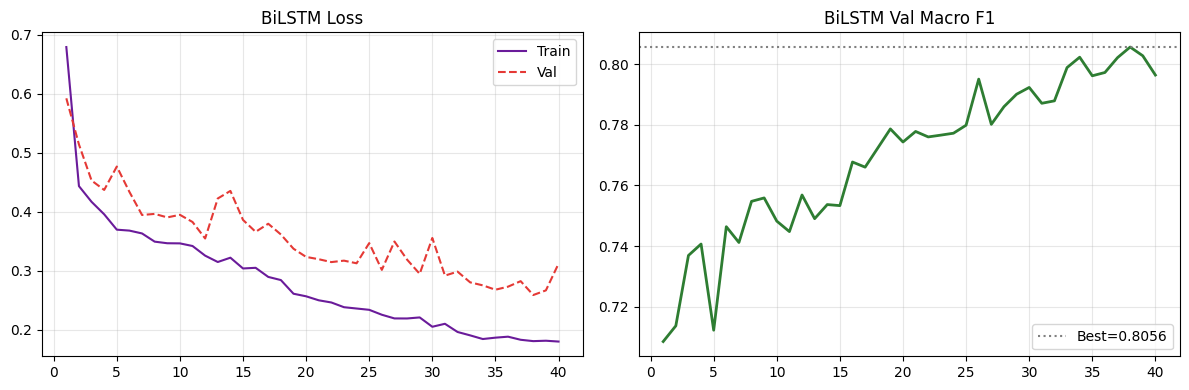

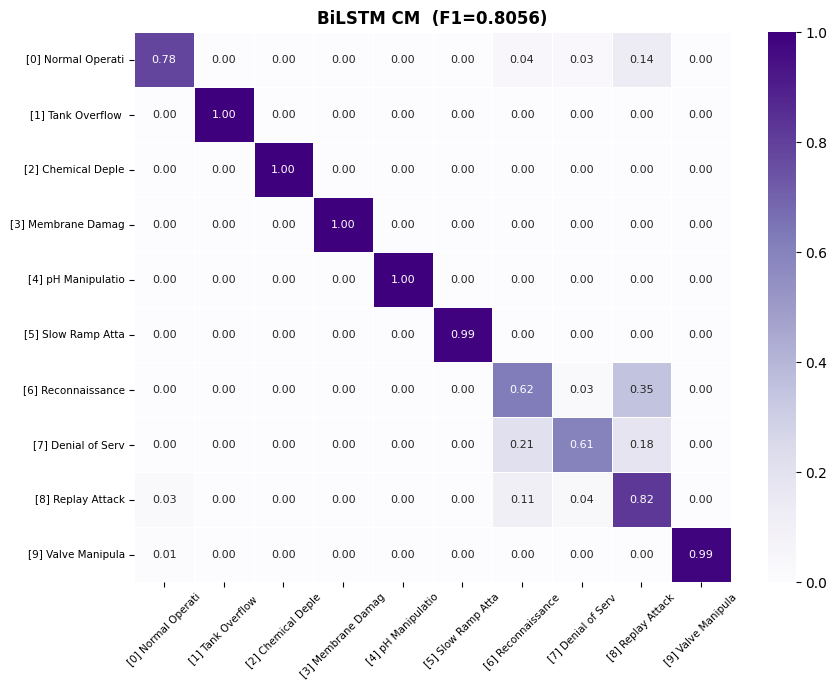

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep_x = range(1, LSTM_EPOCHS+1)
axes[0].plot(ep_x, lstm_hist['tr_loss'], color='#6A1B9A', label='Train')
axes[0].plot(ep_x, lstm_hist['va_loss'], color='#E53935', label='Val', ls='--')
axes[0].set_title("BiLSTM Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep_x, lstm_hist['va_f1'], color='#2E7D32', lw=2)
axes[1].axhline(best_f1_lstm, color='grey', ls=':', label=f'Best={best_f1_lstm:.4f}')
axes[1].set_title("BiLSTM Val Macro F1"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"13_lstm_training.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9,7))
cm = confusion_matrix(y_sq_te, best_preds_lstm, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=short, yticklabels=short,
            ax=ax, linewidths=0.4, annot_kws={'size':8})
ax.set_title(f"BiLSTM CM  (F1={best_f1_lstm:.4f})", fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7.5)
ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"13_lstm_cm.png", dpi=150, bbox_inches='tight')
plt.show()


## 12 · Full Evaluation & Model Comparison

In [60]:
# Per-class F1 across all models
MC_RESULTS = {
    'Random Forest': r_rf_mc,
    'XGBoost':       r_xgb_mc,
    'MLP':           {'y_true':y_te,    'y_pred':best_preds_mc},
    'BiLSTM':        {'y_true':y_sq_te, 'y_pred':best_preds_lstm},
}
f1_rows = {}
for mname, res in MC_RESULTS.items():
    rpt = classification_report(res['y_true'], res['y_pred'],
                                output_dict=True, zero_division=0)
    f1_rows[mname] = {ATTACK_NAMES[i]: rpt.get(str(i),{}).get('f1-score',0.)
                      for i in range(NUM_CLASSES)}
f1_df = pd.DataFrame(f1_rows)
print("Per-class F1 scores:")
print(f1_df.round(4).to_string())


Per-class F1 scores:
                           Random Forest  XGBoost     MLP  BiLSTM
Normal Operation                  0.9307   0.9607  0.8474  0.8760
Tank Overflow Attack              1.0000   1.0000  0.9963  1.0000
Chemical Depletion Attack         1.0000   1.0000  1.0000  1.0000
Membrane Damage Attack            0.9990   0.9949  1.0000  1.0000
pH Manipulation Attack            1.0000   1.0000  0.9991  1.0000
Slow Ramp Attack                  0.9996   0.9992  0.9976  0.9900
Reconnaissance Scan               0.3884   0.7507  0.4052  0.5174
Denial of Service                 0.2359   0.7763  0.2677  0.3580
Replay Attack                     0.0682   0.3364  0.2951  0.3410
Valve Manipulation Attack         0.9826   0.9889  0.8803  0.9738


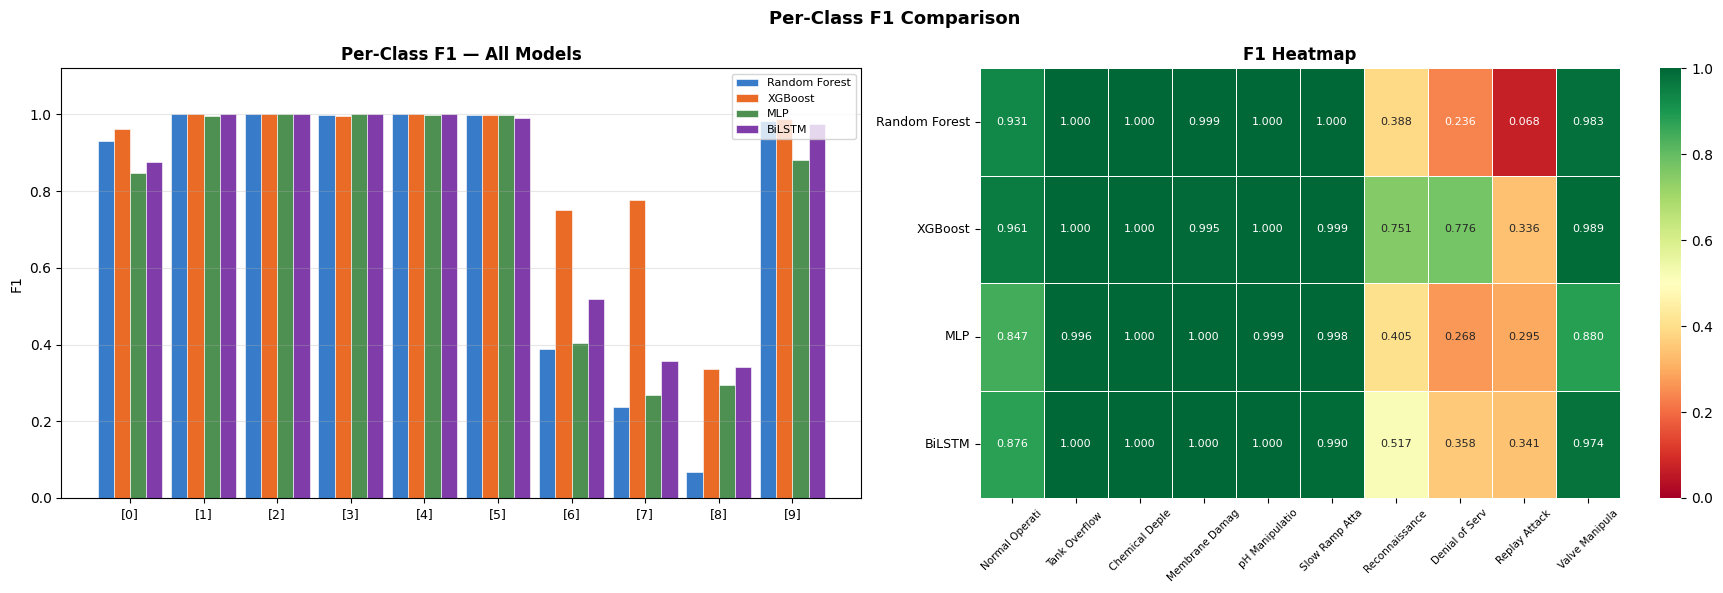

In [61]:
# Per-class F1 grouped bar + heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(NUM_CLASSES); w = 0.22
for k, (mname, col) in enumerate(zip(f1_rows.keys(), ['#1565C0','#E65100','#2E7D32','#6A1B9A'])):
    axes[0].bar(x+k*w-1.5*w, f1_df[mname].values, w, label=mname, color=col,
                alpha=0.85, edgecolor='white', lw=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"[{i}]" for i in range(NUM_CLASSES)], fontsize=9)
axes[0].set_title("Per-Class F1 — All Models", fontweight='bold')
axes[0].set_ylabel("F1"); axes[0].set_ylim(0,1.12)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

sns.heatmap(f1_df.T, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[1],
            xticklabels=[ATTACK_NAMES[i][:14] for i in range(NUM_CLASSES)],
            linewidths=0.5, annot_kws={'size':8})
axes[1].set_title("F1 Heatmap", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7.5)
axes[1].tick_params(axis='y', rotation=0,  labelsize=9)
plt.suptitle("Per-Class F1 Comparison", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR/"14_f1_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [62]:
# Summary table
summary = []
for mname, res in MC_RESULTS.items():
    summary.append({'Model':mname,
                    'Accuracy':  f"{accuracy_score(res['y_true'],res['y_pred']):.4f}",
                    'Macro F1':  f"{f1_score(res['y_true'],res['y_pred'],average='macro',zero_division=0):.4f}",
                    'Weighted F1':f"{f1_score(res['y_true'],res['y_pred'],average='weighted',zero_division=0):.4f}"})
for mname, res in [('RF Binary',r_rf_bin),('XGB Binary',r_xgb_bin),('SVM Binary',r_svm_bin)]:
    summary.append({'Model':mname,
                    'Accuracy':f"{accuracy_score(res['y_true'],res['y_pred']):.4f}",
                    'Macro F1':f"{f1_score(res['y_true'],res['y_pred'],average='macro',zero_division=0):.4f}",
                    'Weighted F1':'—'})
summary.append({'Model':'MLP Binary',
                'Accuracy': f"{accuracy_score(yb_te,best_preds_bin):.4f}",
                'Macro F1': f"{f1_score(yb_te,best_preds_bin,average='macro',zero_division=0):.4f}",
                'Weighted F1':'—'})
print("\n=== FINAL MODEL SUMMARY ===")
print(pd.DataFrame(summary).set_index('Model').to_string())
print(f"\n  Run-4 generalisation F1: {f1_run:.4f}")



=== FINAL MODEL SUMMARY ===
              Accuracy Macro F1 Weighted F1
Model                                      
Random Forest   0.8944   0.7604      0.8748
XGBoost         0.9429   0.8807      0.9315
MLP             0.7737   0.7689      0.8219
BiLSTM          0.8167   0.8056      0.8544
RF Binary       0.8948   0.8756           —
XGB Binary      0.9072   0.8946           —
SVM Binary      0.8894   0.8561           —
MLP Binary      0.8763   0.8618           —

  Run-4 generalisation F1: 0.2908


## 13 · Save All Models

In [63]:
import datetime
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# sklearn / tree models
for fname, obj in {
    "scaler.joblib":         scaler,
    "rf_binary.joblib":      rf_bin,
    "rf_multiclass.joblib":  rf_mc,
    "xgb_binary.joblib":     xgb_bin,
    "xgb_multiclass.joblib": xgb_mc,
    "svm_binary.joblib":     svm_bin,
}.items():
    joblib.dump(obj, MODELS_DIR/fname)
    print(f"  {fname:<35s}  {(MODELS_DIR/fname).stat().st_size/1024:>8.1f} KB")

# PyTorch weights (already saved during training — confirm)
for pt in ["mlp_multiclass_best.pt","mlp_binary_best.pt","lstm_best.pt"]:
    if (MODELS_DIR/pt).exists():
        print(f"  {pt}")

# Best model bundle
bundle = {
    'model':         xgb_mc,
    'scaler':        scaler,
    'feature_cols':  FEATURE_COLS,
    'attack_names':  ATTACK_NAMES,
    'id_remap':      ID_REMAP,
    'model_name':    'XGBoost',
    'macro_f1':      r_xgb_mc['f1'],
    'run4_f1':       f1_run,
    'num_classes':   NUM_CLASSES,
    'temporal_sensors': TEMPORAL_SENSORS,
    'temporal_windows': WINDOW_SIZES,
    'dead_cols':     DEAD_COLS,
    'seq_len':       SEQ_LEN,
    'training_info': {
        'dataset': DATA_PATH, 'total_rows': int(len(df)),
        'smote_targets':{2:4000,3:4000,7:4000},
        'leakage_window_s':4.0, 'test_size':0.20, 'random_state':42,
    }
}
joblib.dump(bundle, MODELS_DIR/"best_model_bundle.joblib", compress=3)
print(f"\n  best_model_bundle.joblib  "
      f"{(MODELS_DIR/'best_model_bundle.joblib').stat().st_size/1024:.1f} KB")

# Metadata JSON
meta = {k: v for k,v in bundle.items()
        if k not in ('model','scaler')}
meta['id_remap'] = {str(k):v for k,v in ID_REMAP.items()}
with open(MODELS_DIR/"pipeline_metadata.json","w") as f:
    _json.dump(meta, f, indent=2)
print("  pipeline_metadata.json")

print("\n=== All saved files ===")
for p in sorted(MODELS_DIR.glob("*")):
    print(f"  {p.name:<40s}  {p.stat().st_size/1024:>8.1f} KB")


  scaler.joblib                             2.1 KB
  rf_binary.joblib                     273076.1 KB
  rf_multiclass.joblib                 1326925.4 KB
  xgb_binary.joblib                      1001.6 KB
  xgb_multiclass.joblib                 11473.0 KB
  svm_binary.joblib                     13840.4 KB
  mlp_multiclass_best.pt
  mlp_binary_best.pt
  lstm_best.pt

  best_model_bundle.joblib  4350.7 KB
  pipeline_metadata.json

=== All saved files ===
  best_model_bundle.joblib                    4350.7 KB
  lstm_best.pt                                2620.3 KB
  mlp_binary_best.pt                           311.0 KB
  mlp_multiclass_best.pt                       971.1 KB
  pipeline_metadata.json                         4.6 KB
  rf_binary.joblib                          273076.1 KB
  rf_multiclass.joblib                      1326925.4 KB
  scaler.joblib                                  2.1 KB
  svm_binary.joblib                          13840.4 KB
  xgb_binary.joblib                   

## 14 · Inference Demo

In [64]:
loaded_scaler = joblib.load(MODELS_DIR/"scaler.joblib")
loaded_xgb    = joblib.load(MODELS_DIR/"xgb_multiclass.joblib")
loaded_rf_bin = joblib.load(MODELS_DIR/"rf_binary.joblib")
print("Models loaded OK")

demo_idx = []
for cls in range(NUM_CLASSES):
    idx = np.where(y_te == cls)[0]
    if len(idx) > 0:
        demo_idx.extend(idx[:3].tolist())

X_demo = X_te_sc[demo_idx]
y_demo = y_te[demo_idx]

y_bin_pred = loaded_rf_bin.predict(X_demo)
y_mc_pred  = loaded_xgb.predict(X_demo)
y_proba    = loaded_xgb.predict_proba(X_demo)

print(f"\n{'True Label':<35} {'Binary':>10} {'Multi-class Pred':<35} {'Conf':>6}  Match")
print("─"*100)
for i in range(len(y_demo)):
    true_n = ATTACK_NAMES[int(y_demo[i])]
    pred_n = ATTACK_NAMES[int(y_mc_pred[i])]
    conf   = y_proba[i, int(y_mc_pred[i])]
    binary = "Attack" if y_bin_pred[i] else "Normal"
    match  = "OK" if y_mc_pred[i]==y_demo[i] else "MISS"
    print(f"[{match}] {true_n:<33}  {binary:>8}   {pred_n:<35} {conf:.3f}")


Models loaded OK

True Label                              Binary Multi-class Pred                      Conf  Match
────────────────────────────────────────────────────────────────────────────────────────────────────
[OK] Normal Operation                     Attack   Normal Operation                    0.942
[OK] Normal Operation                     Normal   Normal Operation                    1.000
[OK] Normal Operation                     Normal   Normal Operation                    1.000
[OK] Tank Overflow Attack                 Attack   Tank Overflow Attack                1.000
[OK] Tank Overflow Attack                 Attack   Tank Overflow Attack                1.000
[OK] Tank Overflow Attack                 Attack   Tank Overflow Attack                0.993
[OK] Chemical Depletion Attack            Attack   Chemical Depletion Attack           1.000
[OK] Chemical Depletion Attack            Attack   Chemical Depletion Attack           1.000
[OK] Chemical Depletion Attack          

## Changes Summary

| Change | Detail |
|--------|--------|
| `DEAD_COLS` updated | Keeps `DPIT_301`, `FIT_301`, `AIT_501-504`, `FIT_501-504`, `PIT_501-503`, `FIT_601`, `MV_303/304`, `UF_Backwash_Active`, `UV_401`, `AIT_402`, `P_403`, `P_501`, `P_601/602`, `P_203`, `P_205` |
| `ReduceLROnPlateau` | `verbose=` argument removed — compatible with PyTorch ≥2.2 |
| Run-based test (Section 6) | Train runs 1-3, test run 4 — detects run-specific overfitting |
| `DPIT_301` in temporal sensors | Added to capture membrane pressure dynamics |

## Deployment
```python
bundle = joblib.load("saved_models/best_model_bundle.joblib")
X_scaled = bundle['scaler'].transform(X_new)   # X_new must use FEATURE_COLS
preds    = bundle['model'].predict(X_scaled)
names    = [bundle['attack_names'][p] for p in preds]
```
